# 🤗 The Hugging Face Ecosystem — A Hands-On Tour

**Goal:** In under an hour, understand and *use* the core pieces of the Hugging Face ecosystem, using only small, fast-to-download models (all under ~250MB, most under 100MB).

### What we'll cover
1. The Hub — where models, datasets & demos live
2. `transformers` — load & run pretrained models in a few lines
3. `tokenizers` — how text becomes numbers
4. `datasets` — load and inspect data at scale
5. `pipeline()` demos: sentiment analysis, text generation, summarization, translation, question answering
6. A tiny fine-tuning example with `Trainer`

## 0. Setup

We only need a handful of libraries. This is the entire Hugging Face "stack" for this demo:

- `transformers` — models & pipelines
- `datasets` — data loading
- `huggingface_hub` — talking to the Hub
- `torch` — the backend (small CPU-friendly models, no GPU needed)


In [3]:
# Uncomment to install (takes ~1-2 min)
!pip install -q transformers datasets huggingface_hub torch accelerate

In [4]:
import transformers, datasets, torch

print("transformers:", transformers.__version__)
print("datasets   :", datasets.__version__)
print("torch      :", torch.__version__)
print("GPU avail? :", torch.cuda.is_available())

transformers: 5.12.1
datasets   : 4.0.0
torch      : 2.11.0+cpu
GPU avail? : False


## 1. The Hugging Face Hub

The **Hub** (https://huggingface.co) is a GitHub-like place for:
- **Models** (500k+) — weights + config + tokenizer, all versioned
- **Datasets** (100k+)
- **Spaces** — free hosted demos (Gradio/Streamlit apps)

Every model has a **model card** describing what it does, its size, license, and how to use it.

Let's search the Hub programmatically for small text-classification models.


In [5]:
from huggingface_hub import HfApi

api = HfApi()

# Search for small sentiment/text-classification models, sorted by downloads
models = api.list_models(
    filter="text-classification",
    sort="downloads",
    limit=5,
)

for m in models:
    print(m.id)

cross-encoder/ms-marco-MiniLM-L6-v2
BAAI/bge-reranker-v2-m3
ProsusAI/finbert
cross-encoder/ms-marco-MiniLM-L4-v2
BAAI/bge-reranker-base


Notice each model ID has the form `<owner>/<model-name>` — just like a GitHub repo.
We'll now actually load one of these.

## 2. `pipeline()` — the fastest way to use a model

`pipeline()` bundles three things together:
1. A **tokenizer** (text → numbers)
2. A **model** (numbers → numbers)
3. A **post-processor** (numbers → human-readable output)

All the models below are deliberately **small** (well under 300MB) so downloads are fast.


### 2.1 Sentiment Analysis
Model: `distilbert-base-uncased-finetuned-sst-2-english` (~260MB, distilled = smaller/faster BERT)


In [6]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

result = classifier([
    "Hugging Face makes NLP so much easier!",
    "This meeting could have been an email."
])

print(result)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9981945157051086},
 {'label': 'NEGATIVE', 'score': 0.9960500597953796}]

### 2.2 Text Generation
Model: `distilgpt2` (~330MB, a distilled version of GPT-2, one of the smallest generative models on the Hub)


In [7]:
generator = pipeline("text-generation", model="distilgpt2")

output = generator(
    "The Hugging Face ecosystem is",
    max_new_tokens=30,
    num_return_sequences=1,
)
print(output[0]["generated_text"])

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_

The Hugging Face ecosystem is one of the most well-known in the world. It’s the first ever “emotional community’to be a place where


### 2.3 Summarization
Model: `sshleifer/distilbart-cnn-6-6` (a distilled BART, ~300MB — one of the smaller summarizers available)

In [8]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

sum_model_name = "sshleifer/distilbart-cnn-6-6"
sum_tokenizer = AutoTokenizer.from_pretrained(sum_model_name)
sum_model = AutoModelForSeq2SeqLM.from_pretrained(sum_model_name)

text = (
    "Hugging Face is a company and open-source community that has become the "
    "central hub for natural language processing and, increasingly, for machine "
    "learning in general. It provides the transformers library, which gives easy "
    "access to thousands of pretrained models, the datasets library for loading "
    "and processing data, and the Hub, a platform for sharing models, datasets, "
    "and interactive demos called Spaces. Together these tools have dramatically "
    "lowered the barrier to using state-of-the-art machine learning models."
)

inputs = sum_tokenizer(text, return_tensors="pt", truncation=True)
summary_ids = sum_model.generate(**inputs, max_length=45, min_length=15)
print(sum_tokenizer.decode(summary_ids[0], skip_special_tokens=True))

config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/460M [00:00<?, ?B/s]

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/262 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/460M [00:00<?, ?B/s]

Hugging Face is a company and open-source community that has become the central hub for natural language processing and machine learning in general . It provides the transformers library, the datasets library for loading and processing data


### 2.4 Translation
Model: `Helsinki-NLP/opus-mt-en-fr` (English→French, ~300MB, part of the huge OPUS-MT family covering 1000+ language pairs)


In [9]:
trans_model_name = "Helsinki-NLP/opus-mt-en-fr"
trans_tokenizer = AutoTokenizer.from_pretrained(trans_model_name)
trans_model = AutoModelForSeq2SeqLM.from_pretrained(trans_model_name)

sentence = "Hugging Face democratizes machine learning."
inputs = trans_tokenizer(sentence, return_tensors="pt")
translated_ids = trans_model.generate(**inputs, max_length=40)
print(trans_tokenizer.decode(translated_ids[0], skip_special_tokens=True))

config.json:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.34M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/301M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Hugging Face démocratise l'apprentissage automatique.


### 2.5 Question Answering
Model: `distilbert-base-cased-distilled-squad` (~260MB)

In [10]:
from transformers import AutoModelForQuestionAnswering
import torch

qa_model_name = "distilbert-base-cased-distilled-squad"
qa_tokenizer = AutoTokenizer.from_pretrained(qa_model_name)
qa_model = AutoModelForQuestionAnswering.from_pretrained(qa_model_name)

context = (
    "Hugging Face was founded in 2016 and is best known for the transformers "
    "library, which supports PyTorch, TensorFlow, and JAX."
)
question = "When was Hugging Face founded?"

inputs = qa_tokenizer(question, context, return_tensors="pt")
with torch.no_grad():
    outputs = qa_model(**inputs)

start = torch.argmax(outputs.start_logits)
end = torch.argmax(outputs.end_logits) + 1
answer = qa_tokenizer.decode(inputs["input_ids"][0][start:end])
print("Answer:", answer)

config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Answer: 2016


## 3. `tokenizers` — how text becomes numbers

Models don't understand words — they understand numbers (token IDs). The tokenizer's job is to:
1. Split text into tokens (often sub-words)
2. Map tokens to IDs the model was trained with
3. Add special tokens (like `[CLS]`, `[SEP]`)


In [11]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

text = "Tokenization can split unfamiliarwords into pieces."
tokens = tokenizer.tokenize(text)
ids = tokenizer.convert_tokens_to_ids(tokens)

print("Tokens:", tokens)
print("IDs   :", ids)

encoded = tokenizer(text, return_tensors="pt")
print("\nFull encoding (with special tokens):")
print(encoded)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokens: ['token', '##ization', 'can', 'split', 'unfamiliar', '##words', 'into', 'pieces', '.']
IDs   : [19204, 3989, 2064, 3975, 16261, 22104, 2046, 4109, 1012]

Full encoding (with special tokens):
{'input_ids': tensor([[  101, 19204,  3989,  2064,  3975, 16261, 22104,  2046,  4109,  1012,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


Notice `unfamiliarwords` got split into sub-word pieces — this is how models handle words they've never seen before without needing an infinite vocabulary.

## 4. `datasets` — loading data at scale

The `datasets` library gives you a single API to stream or download datasets of any size, with built-in caching, and it plays perfectly with `transformers`.

We'll load a **small** dataset: `rotten_tomatoes`.


In [13]:
from datasets import load_dataset

data = load_dataset("cornell-movie-review-data/rotten_tomatoes")
print(data)
print()
print("Example:", data["train"][0])

README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

train.parquet:   0%|          | 0.00/699k [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/90.0k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/92.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

Example: {'text': 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'label': 1}


In [14]:
# Quick peek as a table
import pandas as pd
pd.DataFrame(data["train"][:5])

,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1


## 5. A Tiny Fine-Tuning Example

Let's put it all together: tokenizer + dataset + model + `Trainer`, using a **very small** model  and a tiny slice of data, so this runs in under a minute on CPU.

This is only meant to show the *shape* of a fine-tuning workflow, not to produce a great model.


In [22]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np

model_name = "google/bert_uncased_L-2_H-128_A-2"  # tiny BERT: 2 layers, 128 hidden units

tiny_tokenizer = AutoTokenizer.from_pretrained(model_name)
tiny_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Use a small slice so the demo runs fast
small_train = data["train"].shuffle(seed=42).select(range(200))
small_eval = data["validation"].shuffle(seed=42).select(range(50))

def preprocess(batch):
    return tiny_tokenizer(batch["text"], truncation=True, padding="max_length", max_length=64)

small_train = small_train.map(preprocess, batched=True)
small_eval = small_eval.map(preprocess, batched=True)

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-2_H-128_A-2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [23]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": (preds == labels).mean()}

args = TrainingArguments(
    output_dir="./tiny-finetune-demo",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=5e-4,       # 10x higher — tiny models need a bigger push
    warmup_ratio=0.1,
    eval_strategy="epoch",
    logging_steps=10,
    report_to=[],
)

trainer = Trainer(
    model=tiny_model,
    args=args,
    train_dataset=small_train,
    eval_dataset=small_eval,
    compute_metrics=compute_metrics,
)

trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.679357,0.679075,0.540000
2,0.587379,0.598606,0.780000
3,0.340012,0.619906,0.700000
4,0.089065,0.675700,0.720000
5,0.072304,0.769654,0.720000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=125, training_loss=0.3780132281780243, metrics={'train_runtime': 10.3169, 'train_samples_per_second': 96.928, 'train_steps_per_second': 12.116, 'total_flos': 158810880000.0, 'train_loss': 0.3780132281780243, 'epoch': 5.0})

In [24]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy
0.072304,0.769654,5,0.720000


{'eval_loss': 0.7696536183357239, 'eval_accuracy': 0.72}

That's the whole loop: **tokenizer → dataset → model → Trainer → evaluate**.

In [26]:
sample_text = "This movie was a junk, bad and waste of time."

inputs = tiny_tokenizer(sample_text, return_tensors="pt", truncation=True, padding=True, max_length=64)
with torch.no_grad():
    logits = tiny_model(**inputs).logits

pred = torch.argmax(logits, dim=-1).item()
label_map = {0: "negative", 1: "positive"}
print(f"Text: {sample_text}")
print(f"Prediction: {label_map[pred]}")

Text: This movie was a junk, bad and waste of time.
Prediction: negative


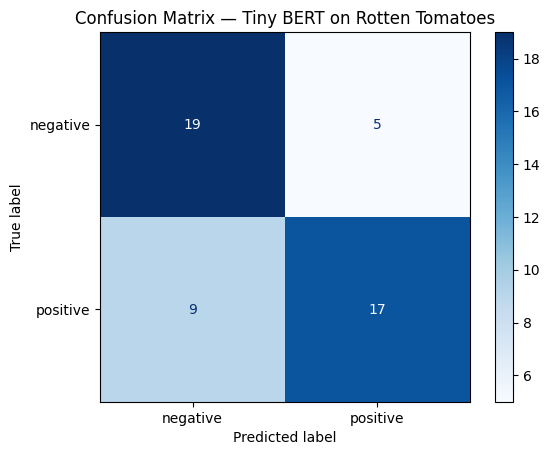

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = trainer.predict(small_eval)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix ")
plt.show()